# Phase 1.1: Feature Engineering for Healthcare Claims Coverage Prediction

This notebook handles all data preprocessing and feature engineering required for building ML models to predict:
1. Coverage Eligibility (Binary Classification)
2. Coverage Amount (Regression)

The goal is to prepare clean, properly encoded features that capture all relevant information from the merged healthcare claims and policy dataset.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries imported successfully
Pandas: 2.3.2
NumPy: 2.3.3


## Load Merged Dataset

In [2]:
# Load the merged dataset
data_path = Path('../outputs/merged.csv')
df = pd.read_csv(data_path)

print(f"Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\nFirst 3 rows:")
df.head(3)

Dataset loaded: 55,500 rows, 27 columns

Columns:
 1. claim_id
 2. age
 3. gender
 4. medical_condition
 5. admission_type
 6. insurance_provider
 7. billing_amount
 8. length_of_stay_days
 9. provider_id
10. provider_name
11. plan_type
12. coverage_percentage
13. max_coverage_amount
14. copay_percentage
15. deductible_amount
16. annual_out_of_pocket_max
17. excluded_conditions
18. medication_coverage
19. diagnostic_test_coverage
20. admission_type_rules
21. waiting_period
22. pre_existing_condition_coverage
23. network_coverage
24. emergency_coverage
25. preventive_care_coverage
26. created_date
27. data_source

First 3 rows:


,claim_id,age,gender,medical_condition,admission_type,insurance_provider,billing_amount,length_of_stay_days,provider_id,provider_name,plan_type,coverage_percentage,max_coverage_amount,copay_percentage,deductible_amount,annual_out_of_pocket_max,excluded_conditions,medication_coverage,diagnostic_test_coverage,admission_type_rules,waiting_period,pre_existing_condition_coverage,network_coverage,emergency_coverage,preventive_care_coverage,created_date,data_source
0,1,30,Male,Cancer,Urgent,Blue Cross,18856.281306,2,1,Blue Cross,PPO Standard,80.0,Unlimited,20.0,1500.0,8000.0,"Cosmetic surgery, Self-inflicted injuries, Exp...","Generic: $7.50 copay, Preferred brand: 30% coi...",80.0,"Precertification required for inpatient stays,...",0,0,Nationwide PPO network with extensive provider...,"Covered in and out of network, standard copays...",100.0,2025-09-29T16:16:14.205237,2025 Official Plan Documents
1,2,62,Male,Obesity,Emergency,Medicare,33643.327287,6,2,Medicare,Original Medicare (Parts A & B),80.0,Unlimited,20.0,1676.0,No limit,"Cosmetic surgery, Routine dental/vision/hearin...","Part D separate - varies by plan, $2000 OOP ma...",80.0,"Part A: $1676 deductible per benefit period, t...",0,0,Any Medicare-accepting provider nationwide,Covered nationwide and limited international,100.0,2025-09-29T16:16:14.205242,2025 Official Plan Documents
2,3,76,Female,Obesity,Emergency,Aetna,27955.096079,15,3,Aetna,Choice POS II Standard,80.0,Unlimited,20.0,750.0,6500.0,"Cosmetic treatments, Self-inflicted injuries, ...","Formulary-based tiered copays, Generic preferr...",100.0,"Precertification required, Hospital copay per ...",0,0,"POS with large provider network, optional PCP",Covered in and out of network with standard co...,100.0,2025-09-29T16:16:14.205243,2025 Official Plan Documents


## Create Target Variables

We need to create two target variables:
1. **is_covered** (Binary): Whether the claim is covered by the insurance policy
2. **covered_amount** (Continuous): The actual amount covered after deductible and copay

### Coverage Logic:
- Check if medical condition is in excluded conditions
- If not excluded: Calculate covered amount = (billing_amount - deductible) × coverage_percentage × (1 - copay_percentage/100)
- Ensure covered amount doesn't exceed policy limits

Creating target variables...

Coverage Statistics:
Total claims: 55,500
Covered claims: 46,269 (83.4%)
Denied claims: 9,231 (16.6%)

Covered Amount Statistics (for covered claims):
Mean covered amount: $15,397.53
Median covered amount: $15,333.67
Min covered amount: $0.00
Max covered amount: $33,038.74


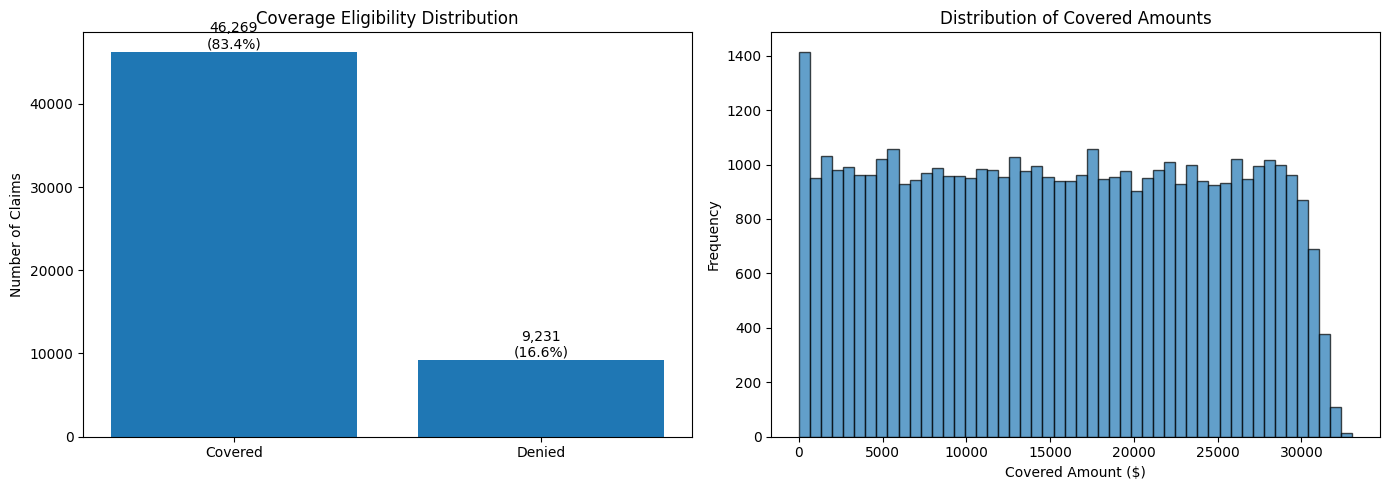

In [3]:
def check_coverage_eligibility(row):
    """
    Determine if a claim is covered based on policy exclusions.
    Returns True if covered, False if excluded.
    """
    medical_condition = str(row['medical_condition']).lower()
    excluded_conditions = str(row['excluded_conditions']).lower()
    
    # Check if the condition is mentioned in exclusions
    # Common exclusions: cosmetic, experimental, self-inflicted, substance abuse
    condition_keywords = {
        'cancer': ['cancer', 'oncology', 'tumor', 'malignancy'],
        'diabetes': ['diabetes', 'diabetic'],
        'obesity': ['obesity', 'weight loss surgery', 'bariatric'],
        'hypertension': ['hypertension', 'blood pressure'],
        'asthma': ['asthma', 'respiratory'],
        'arthritis': ['arthritis', 'joint']
    }
    
    # Most standard conditions are covered unless explicitly excluded
    # Obesity might have restrictions in some policies
    if medical_condition == 'obesity':
        # Check if cosmetic or bariatric surgery is excluded
        if any(term in excluded_conditions for term in ['cosmetic', 'weight loss', 'bariatric']):
            return False
    
    # Cancer, diabetes, hypertension, asthma, arthritis are typically covered
    # unless marked as experimental treatment
    return True


def calculate_covered_amount(row):
    """
    Calculate the actual covered amount based on policy rules.
    Formula: max(0, (billing_amount - deductible) * (coverage_percentage/100) * (1 - copay_percentage/100))
    """
    if not row['is_covered']:
        return 0.0
    
    billing = row['billing_amount']
    deductible = row['deductible_amount']
    coverage_pct = row['coverage_percentage'] / 100
    copay_pct = row['copay_percentage'] / 100
    
    # Calculate covered amount
    # Step 1: Subtract deductible
    after_deductible = max(0, billing - deductible)
    
    # Step 2: Apply coverage percentage
    covered_by_insurance = after_deductible * coverage_pct
    
    # Step 3: Patient pays copay percentage of the covered amount
    final_covered = covered_by_insurance * (1 - copay_pct)
    
    return max(0, final_covered)


# Create target variables
print("Creating target variables...")
df['is_covered'] = df.apply(check_coverage_eligibility, axis=1)
df['covered_amount'] = df.apply(calculate_covered_amount, axis=1)

print(f"\nCoverage Statistics:")
print(f"Total claims: {len(df):,}")
print(f"Covered claims: {df['is_covered'].sum():,} ({df['is_covered'].mean()*100:.1f}%)")
print(f"Denied claims: {(~df['is_covered']).sum():,} ({(~df['is_covered']).mean()*100:.1f}%)")
print(f"\nCovered Amount Statistics (for covered claims):")
covered_df = df[df['is_covered']]
print(f"Mean covered amount: ${covered_df['covered_amount'].mean():,.2f}")
print(f"Median covered amount: ${covered_df['covered_amount'].median():,.2f}")
print(f"Min covered amount: ${covered_df['covered_amount'].min():,.2f}")
print(f"Max covered amount: ${covered_df['covered_amount'].max():,.2f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coverage distribution
coverage_counts = df['is_covered'].value_counts()
axes[0].bar(['Covered', 'Denied'], coverage_counts.values)
axes[0].set_title('Coverage Eligibility Distribution')
axes[0].set_ylabel('Number of Claims')
for i, v in enumerate(coverage_counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom')

# Covered amount distribution
axes[1].hist(covered_df['covered_amount'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Covered Amounts')
axes[1].set_xlabel('Covered Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Feature Engineering

Create additional features that might help predict coverage and amounts:
1. Age groups
2. Cost tiers
3. Length of stay categories
4. Risk scores
5. Provider-specific features

In [4]:
print("Engineering additional features...")

# 1. Age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100], 
                          labels=['0-17', '18-34', '35-49', '50-64', '65+'])

# 2. Cost tiers
df['cost_tier'] = pd.cut(df['billing_amount'], 
                          bins=[0, 10000, 20000, 30000, 40000, float('inf')],
                          labels=['Low', 'Medium', 'High', 'Very High', 'Critical'])

# 3. Length of stay categories
df['stay_category'] = pd.cut(df['length_of_stay_days'],
                              bins=[0, 1, 3, 7, 14, float('inf')],
                              labels=['Same day', 'Short', 'Medium', 'Long', 'Extended'])

# 4. Out-of-pocket estimate (for patient)
df['estimated_out_of_pocket'] = df['billing_amount'] - df['covered_amount']

# 5. Coverage ratio (what percentage is actually covered)
df['coverage_ratio'] = df['covered_amount'] / df['billing_amount']
df['coverage_ratio'] = df['coverage_ratio'].fillna(0)

# 6. High risk flag (based on age and condition)
high_risk_conditions = ['Cancer', 'Diabetes']
df['high_risk'] = ((df['age'] > 65) | (df['medical_condition'].isin(high_risk_conditions))).astype(int)

# 7. Emergency flag
df['is_emergency'] = (df['admission_type'] == 'Emergency').astype(int)

print(f"\nNew features created:")
new_features = ['age_group', 'cost_tier', 'stay_category', 'estimated_out_of_pocket', 
                'coverage_ratio', 'high_risk', 'is_emergency']
for feat in new_features:
    print(f"  - {feat}")

print(f"\nFeature summary:")
print(f"Age groups distribution:\n{df['age_group'].value_counts()}\n")
print(f"Cost tiers distribution:\n{df['cost_tier'].value_counts()}\n")
print(f"Stay categories distribution:\n{df['stay_category'].value_counts()}\n")

Engineering additional features...

New features created:
  - age_group
  - cost_tier
  - stay_category
  - estimated_out_of_pocket
  - coverage_ratio
  - high_risk
  - is_emergency

Feature summary:
Age groups distribution:
age_group
65+      16250
18-34    13644
50-64    12417
35-49    12301
0-17       888
Name: count, dtype: int64

Cost tiers distribution:
cost_tier
Critical     11430
High         11391
Very High    11240
Medium       11187
Low          10252
Name: count, dtype: int64

Stay categories distribution:
stay_category
Extended    29505
Long        13009
Medium       7484
Short        3685
Same day     1817
Name: count, dtype: int64



## Encode Categorical Variables

Convert categorical variables to numerical format using Label Encoding for tree-based models.

In [5]:
print("Encoding categorical variables...")

# Create a copy for ML features
df_ml = df.copy()

# Categorical columns to encode
categorical_cols = ['gender', 'medical_condition', 'admission_type', 'insurance_provider', 
                    'plan_type', 'age_group', 'cost_tier', 'stay_category']

# Store encoders for later use
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_ml[f'{col}_encoded'] = le.fit_transform(df_ml[col].astype(str))
    encoders[col] = le
    print(f"  Encoded {col}: {len(le.classes_)} classes")

# Save encoders for deployment
encoders_path = Path('trained_models/label_encoders.pkl')
joblib.dump(encoders, encoders_path)
print(f"\nLabel encoders saved to: {encoders_path}")

# Show encoding mapping for reference
print(f"\nExample encoding mappings:")
for col in ['gender', 'medical_condition', 'admission_type']:
    print(f"\n{col}:")
    for i, class_name in enumerate(encoders[col].classes_):
        print(f"  {class_name} -> {i}")

Encoding categorical variables...
  Encoded gender: 2 classes
  Encoded medical_condition: 6 classes
  Encoded admission_type: 3 classes
  Encoded insurance_provider: 5 classes
  Encoded plan_type: 5 classes
  Encoded age_group: 5 classes
  Encoded cost_tier: 5 classes
  Encoded stay_category: 5 classes

Label encoders saved to: trained_models/label_encoders.pkl

Example encoding mappings:

gender:
  Female -> 0
  Male -> 1

medical_condition:
  Arthritis -> 0
  Asthma -> 1
  Cancer -> 2
  Diabetes -> 3
  Hypertension -> 4
  Obesity -> 5

admission_type:
  Elective -> 0
  Emergency -> 1
  Urgent -> 2


## Prepare Feature Sets

Select and prepare final feature sets for both classification and regression tasks.

In [6]:
print("Preparing feature sets for ML models...")

# Define feature columns (encoded versions)
feature_cols = [
    # Encoded categorical features
    'gender_encoded',
    'medical_condition_encoded',
    'admission_type_encoded',
    'insurance_provider_encoded',
    'plan_type_encoded',
    'age_group_encoded',
    'cost_tier_encoded',
    'stay_category_encoded',
    
    # Numerical features
    'age',
    'billing_amount',
    'length_of_stay_days',
    'coverage_percentage',
    'deductible_amount',
    'copay_percentage',
    'diagnostic_test_coverage',
    'preventive_care_coverage',
    
    # Engineered features
    'high_risk',
    'is_emergency'
]

# Verify all features exist
missing_features = [col for col in feature_cols if col not in df_ml.columns]
if missing_features:
    print(f"Warning: Missing features: {missing_features}")
    feature_cols = [col for col in feature_cols if col in df_ml.columns]

print(f"\nTotal features selected: {len(feature_cols)}")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

# Prepare X and y for classification
X_classification = df_ml[feature_cols].copy()
y_classification = df_ml['is_covered'].copy()

# Prepare X and y for regression (only for covered claims)
covered_mask = df_ml['is_covered'] == True
X_regression = df_ml.loc[covered_mask, feature_cols].copy()
y_regression = df_ml.loc[covered_mask, 'covered_amount'].copy()

print(f"\nClassification dataset:")
print(f"  Features shape: {X_classification.shape}")
print(f"  Target shape: {y_classification.shape}")
print(f"  Class distribution: {y_classification.value_counts().to_dict()}")

print(f"\nRegression dataset (covered claims only):")
print(f"  Features shape: {X_regression.shape}")
print(f"  Target shape: {y_regression.shape}")
print(f"  Target range: ${y_regression.min():.2f} to ${y_regression.max():.2f}")
print(f"  Target mean: ${y_regression.mean():.2f}")

Preparing feature sets for ML models...

Total features selected: 18
 1. gender_encoded
 2. medical_condition_encoded
 3. admission_type_encoded
 4. insurance_provider_encoded
 5. plan_type_encoded
 6. age_group_encoded
 7. cost_tier_encoded
 8. stay_category_encoded
 9. age
10. billing_amount
11. length_of_stay_days
12. coverage_percentage
13. deductible_amount
14. copay_percentage
15. diagnostic_test_coverage
16. preventive_care_coverage
17. high_risk
18. is_emergency

Classification dataset:
  Features shape: (55500, 18)
  Target shape: (55500,)
  Class distribution: {True: 46269, False: 9231}

Regression dataset (covered claims only):
  Features shape: (46269, 18)
  Target shape: (46269,)
  Target range: $0.00 to $33038.74
  Target mean: $15397.53


## Train-Test Split

Split data into training, validation, and test sets (70/15/15).

In [7]:
print("Splitting datasets...")

# Classification splits (stratified by target)
X_train_cls, X_temp_cls, y_train_cls, y_temp_cls = train_test_split(
    X_classification, y_classification, test_size=0.3, random_state=42, stratify=y_classification
)

X_val_cls, X_test_cls, y_val_cls, y_test_cls = train_test_split(
    X_temp_cls, y_temp_cls, test_size=0.5, random_state=42, stratify=y_temp_cls
)

print("Classification splits:")
print(f"  Train: {X_train_cls.shape[0]:,} samples ({X_train_cls.shape[0]/len(X_classification)*100:.1f}%)")
print(f"  Val:   {X_val_cls.shape[0]:,} samples ({X_val_cls.shape[0]/len(X_classification)*100:.1f}%)")
print(f"  Test:  {X_test_cls.shape[0]:,} samples ({X_test_cls.shape[0]/len(X_classification)*100:.1f}%)")

# Regression splits
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_regression, y_regression, test_size=0.3, random_state=42
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.5, random_state=42
)

print(f"\nRegression splits (covered claims only):")
print(f"  Train: {X_train_reg.shape[0]:,} samples ({X_train_reg.shape[0]/len(X_regression)*100:.1f}%)")
print(f"  Val:   {X_val_reg.shape[0]:,} samples ({X_val_reg.shape[0]/len(X_regression)*100:.1f}%)")
print(f"  Test:  {X_test_reg.shape[0]:,} samples ({X_test_reg.shape[0]/len(X_regression)*100:.1f}%)")

Splitting datasets...
Classification splits:
  Train: 38,850 samples (70.0%)
  Val:   8,325 samples (15.0%)
  Test:  8,325 samples (15.0%)

Regression splits (covered claims only):
  Train: 32,388 samples (70.0%)
  Val:   6,940 samples (15.0%)
  Test:  6,941 samples (15.0%)


## Save Processed Data

Save all processed datasets and metadata for model training.

In [8]:
print("Saving processed datasets...")

# Create dictionary of all datasets
processed_data = {
    # Classification data
    'X_train_cls': X_train_cls,
    'X_val_cls': X_val_cls,
    'X_test_cls': X_test_cls,
    'y_train_cls': y_train_cls,
    'y_val_cls': y_val_cls,
    'y_test_cls': y_test_cls,
    
    # Regression data
    'X_train_reg': X_train_reg,
    'X_val_reg': X_val_reg,
    'X_test_reg': X_test_reg,
    'y_train_reg': y_train_reg,
    'y_val_reg': y_val_reg,
    'y_test_reg': y_test_reg,
    
    # Feature names
    'feature_cols': feature_cols
}

# Save to pickle file
data_path = Path('trained_models/processed_data.pkl')
joblib.dump(processed_data, data_path)
print(f"Processed data saved to: {data_path}")

# Save full processed dataframe for reference
df_ml_path = Path('../outputs/processed_ml_dataset.csv')
df_ml.to_csv(df_ml_path, index=False)
print(f"Full processed dataset saved to: {df_ml_path}")

# Save feature metadata
metadata = {
    'n_features': len(feature_cols),
    'feature_names': feature_cols,
    'categorical_features': [col for col in feature_cols if '_encoded' in col],
    'numerical_features': [col for col in feature_cols if '_encoded' not in col],
    'classification_classes': y_classification.unique().tolist(),
    'regression_target_stats': {
        'min': float(y_regression.min()),
        'max': float(y_regression.max()),
        'mean': float(y_regression.mean()),
        'median': float(y_regression.median())
    }
}

metadata_path = Path('trained_models/feature_metadata.pkl')
joblib.dump(metadata, metadata_path)
print(f"Feature metadata saved to: {metadata_path}")

print("\nFeature Engineering Complete!")
print("=" * 50)
print(f"Ready for model training with {len(feature_cols)} features")
print(f"Classification: {len(X_train_cls):,} training samples")
print(f"Regression: {len(X_train_reg):,} training samples")

Saving processed datasets...
Processed data saved to: trained_models/processed_data.pkl
Full processed dataset saved to: ../outputs/processed_ml_dataset.csv
Feature metadata saved to: trained_models/feature_metadata.pkl

Feature Engineering Complete!
Ready for model training with 18 features
Classification: 38,850 training samples
Regression: 32,388 training samples
